# Diffusion equation with time-dependent Neumann boundary conditions

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, L_x] \\
u_0(x) = \epsilon^2(1 - e^{-x/\epsilon})  \\
u_{\text{N}}(x=0, t)=\epsilon\cos(\omega t) \\
u_{\text{N}}(x=L_x)=0 \\
\mathsf{D}=\mathsf{I} \\
R=-1 \\
J=1 \\
\end{cases}
$$

In [ ]:
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fdm import (
    BE, finite_difference_order,
    FiniteDifference, FunctionSeries, ConstantSeries,
)
from lucifex.sim import run, Simulation
from lucifex.fem import Constant
from lucifex.solver import ibvp, evaluation, BoundaryConditions
from lucifex.plt import plot_line, create_animation, save_figure, display_animation
from lucifex.pde.diffusion import diffusion

def cosine_wave(t, eps, omega):
    return eps * np.cos(omega * float(t))

def create_simulation(
    Lx: float,
    Nx: int,
    dt: float,
    eps: float,
    omega: float,
    D_diff: FiniteDifference,
    D_reac: FiniteDifference,
    bcs_auto: bool,
) -> Simulation:
    order = finite_difference_order(D_diff, D_reac)
    store = 1
    mesh = interval_mesh(Lx, Nx)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')  
    d = Constant(mesh, 1.0, 'd')
    u = FunctionSeries(
        (mesh, 'P', 1), 
        'u', 
        order, 
        store, 
        ics=lambda x: (eps ** 2) * (1 - np.exp(-x[0] / eps))
    )
    uN = ConstantSeries(
        mesh, 
        'uN',
        order, 
        store=store, 
        ics=cosine_wave(0.0, eps, omega),
    )
    uN_solver = evaluation(uN, cosine_wave, future=True)(t[0] + dt, eps, omega)
    bcs = BoundaryConditions(
        ('neumann', lambda x: x[0], uN[1]),
        ('neumann', lambda x: x[0] - Lx, 0.0),
        neumann=lambda v, uW: -v * uW,
    )
    if bcs_auto:
        u_solver = ibvp(diffusion, bcs=bcs)(u, dt, d, D_diff)
    else:
        u_solver = ibvp(diffusion)(u, dt, d, D_diff, bcs=bcs)
    return Simulation([uN_solver, u_solver], t, dt)


Lx = 1.0
Nx = 100
dt = 0.01
eps = 0.1
omega = 20

simulations: dict[bool, Simulation] = {}
for bcs_auto in (True, False):
    simulation = create_simulation(Lx, Nx, dt, eps, omega, BE, BE, bcs_auto)
    n_stop = 20 #50
    run(simulation, n_stop)
    simulations[bcs_auto] = simulation

In [3]:
anim_paths: dict[bool, str] = {}
for bcs_auto, sim in simulations.items():
    u = sim['u']
    u_min = np.min([np.min(dofs) for dofs in u.dofs_series])
    u_max = np.max([np.max(dofs) for dofs in u.dofs_series])

    y_label_series = [f'$u(t={t:.2f}$)' for t in u.time_series]
    anim = create_animation(
        plot_line,
        y_lims=(u_min, u_max),
        x_label='$x$', 
    )(u.series, y_label=y_label_series)
    anim_path = save_figure(f'u(x,t)_{bcs_auto}', return_path=True)(anim)
    anim_paths[bcs_auto] = anim_path

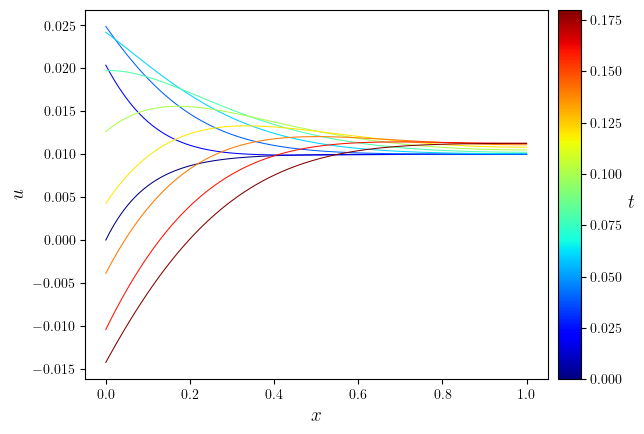

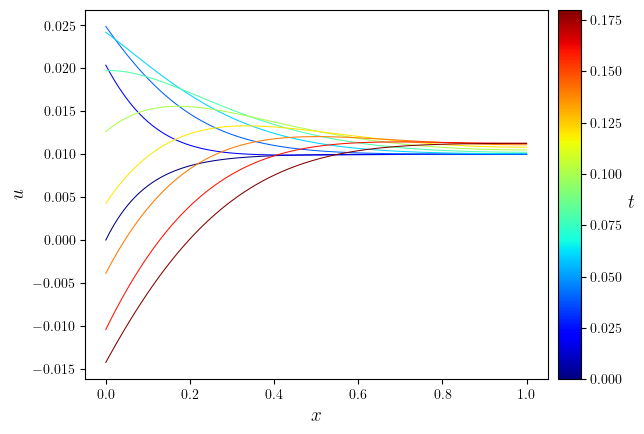

In [6]:
slc = slice(0, None, 2)

for bcs_auto, sim in simulations.items():
    u = sim['u']
    legend_labels=(min(u.time_series[slc]), max(u.time_series[slc]))
    fig, ax = plot_line(u.series[slc], legend_labels, '$t$', cyc='jet', x_label='$x$', y_label='$u$')
    save_figure(f'u(x,t)_{bcs_auto}', thumbnail=bcs_auto)(fig)

In [4]:
display_animation(anim_paths[True])

In [5]:
display_animation(anim_paths[False])